**Project Name: Credit Risk Prediction**

Project Sponser: Mr. KIV Sithvuthy

Project Team
Mr. SOK Khosara and Mr. SOM Rakmey

I. Overview
This project had been implemented to complete Machine Learning course requirement. Project member had selected “Credit Risk Prediction” with Machine Learning uses historical financial and behavioral data to build models that estimate the likelihood of a borrower defaulting, helping lenders make more accurate and efficient lending decisions while reducing financial risk.

II. Objective
The objective of Credit Risk Prediction with Machine Learning is to develop accurate and reliable models that assess the probability of borrower default, enabling financial institutions to make informed lending decisions, minimize risk, and improve overall portfolio performance.


III. Technical Solutions
1. Library Needed

In [155]:
pip install imbalanced-learn lightgbm flask requests


   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]

Note: you may need to restart the kernel to use updated packages.


In [27]:
# Stsandard libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
from datetime import datetime
import time
from matplotlib.gridspec import GridSpec

In [29]:
import sys
import os
print(os.listdir())

['credit_data.csv', 'Khosara_Smey_Project_CreditRiskPrediction.ipynb']


In [30]:
# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [121]:
# Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, cross_val_predict, \
                                    learning_curve
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, \
    accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

2. Import and Exploring the Data

In [42]:
# Data path
df_ori = pd.read_csv(r'D:\Khosara\Training - Data Science\ML VS Code\Final Project\credit_data.csv')
df = df_ori.iloc[:, 1:]
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

# Results
print(f'Data dimension: {df.shape}')
df.head()

Data dimension: (1000, 10)


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [43]:
# Overview data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1000 non-null   int64
 1   sex               1000 non-null   str  
 2   job               1000 non-null   int64
 3   housing           1000 non-null   str  
 4   saving_accounts   817 non-null    str  
 5   checking_account  606 non-null    str  
 6   credit_amount     1000 non-null   int64
 7   duration          1000 non-null   int64
 8   purpose           1000 non-null   str  
 9   risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [ ]:
# Overview unique value
for col in df.columns:
    print(f"{col}: {df[col].unique()}\n")

age: [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]

sex: <StringArray>
['male', 'female']
Length: 2, dtype: str

job: [2 1 3 0]

housing: <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

saving_accounts: <StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

checking_account: <StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

credit_amount: [ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436

In [ ]:
df['sex_flag'] = (df['sex'] == 'male').astype(int)
df['risk_flag'] = (df['risk'] == 'good').astype(int)

df['saving_accounts'] = df['saving_accounts'].fillna(df['saving_accounts'].mode()[0])
df['checking_account'] = df['checking_account'].fillna(df['checking_account'].mode()[0])
df.isna().sum()

age                 0
sex                 0
job                 0
housing             0
saving_accounts     0
checking_account    0
credit_amount       0
duration            0
purpose             0
risk                0
risk_flag           0
sex_flag            0
dtype: int64

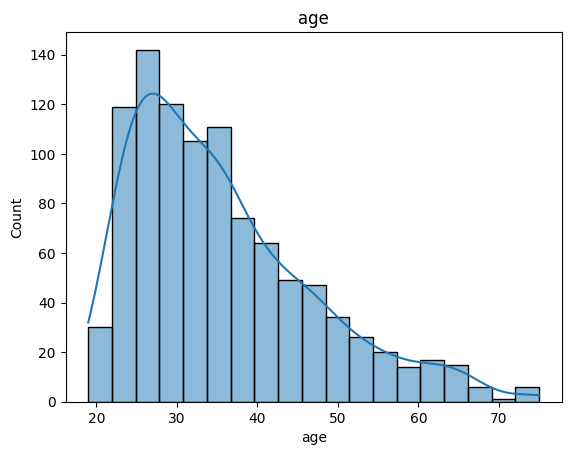

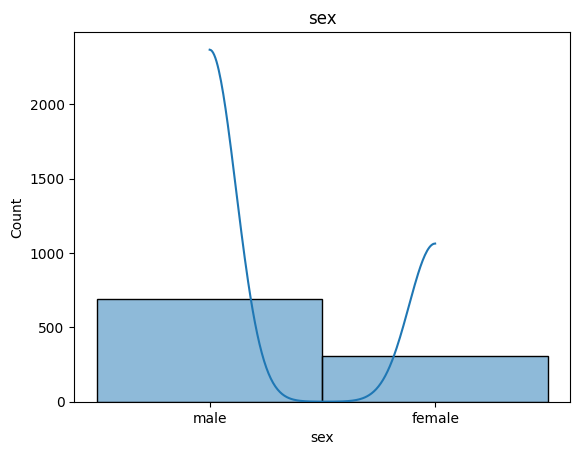

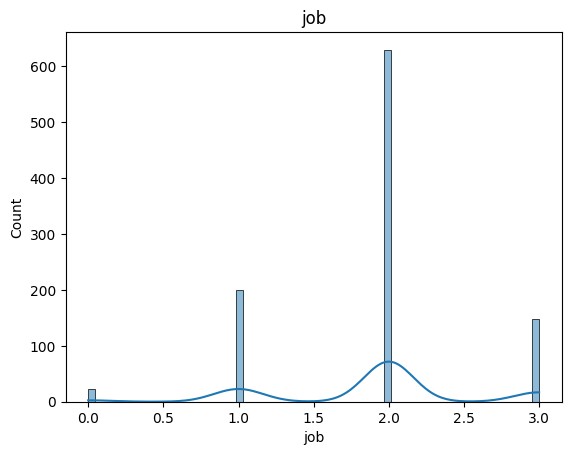

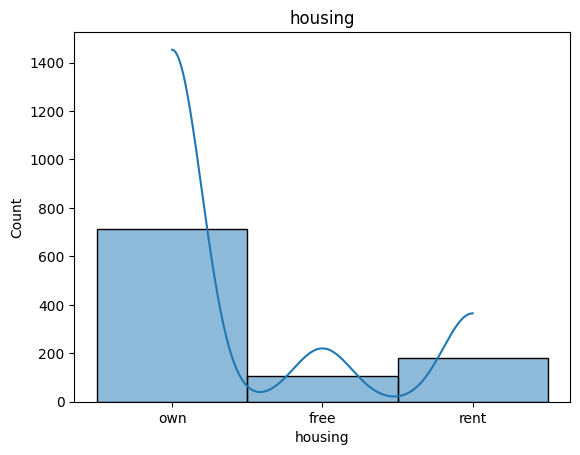

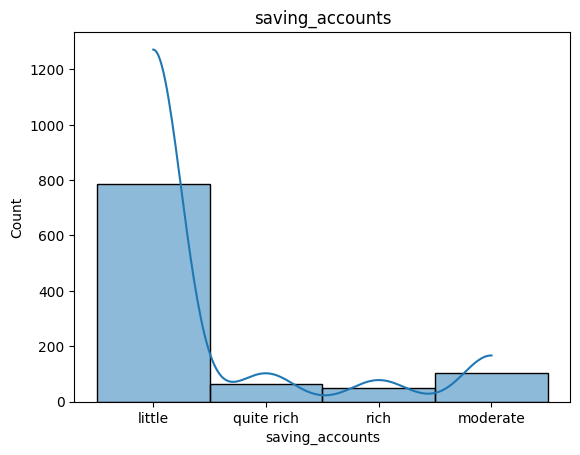

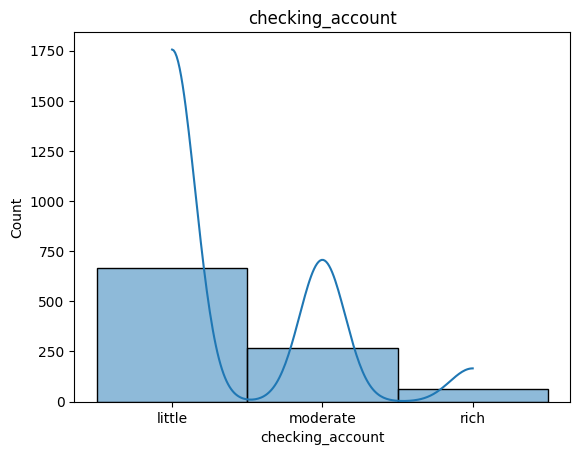

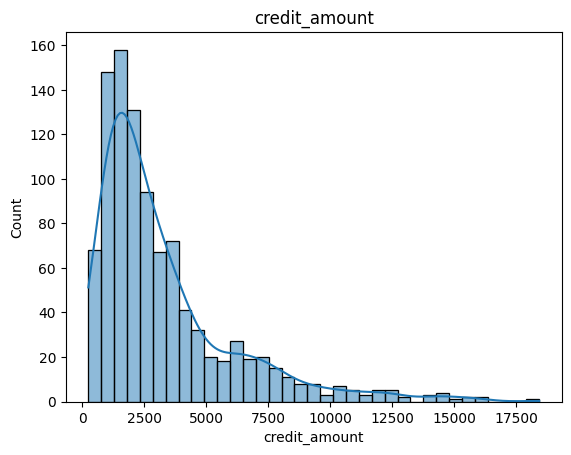

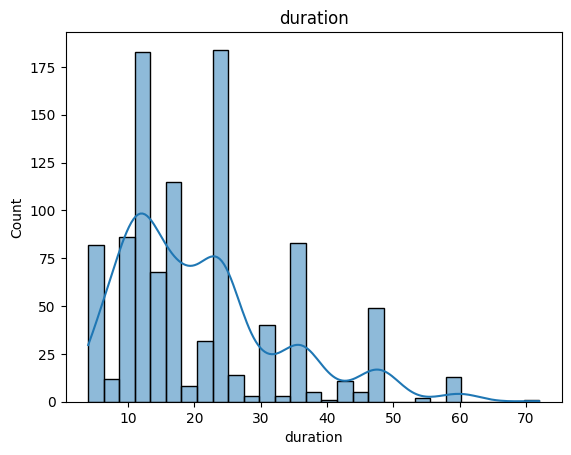

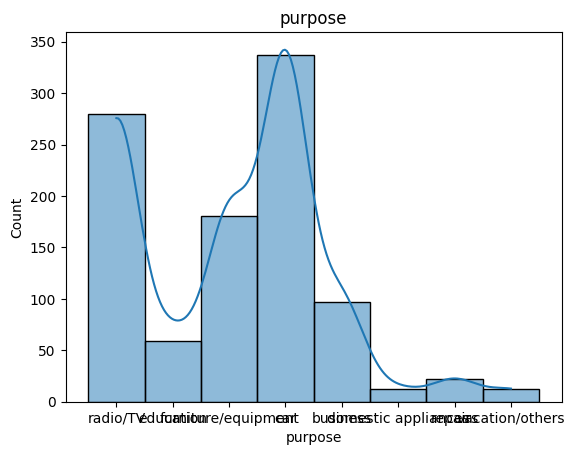

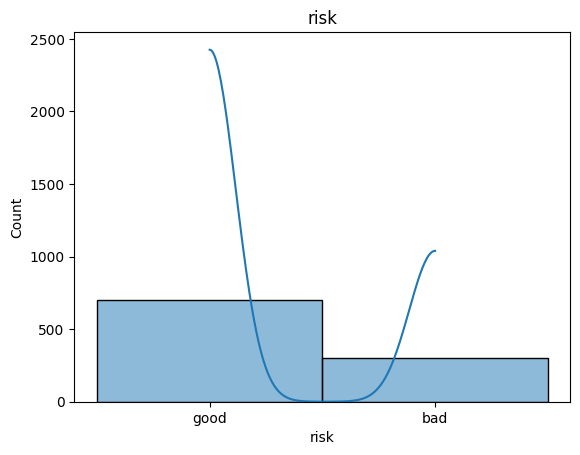

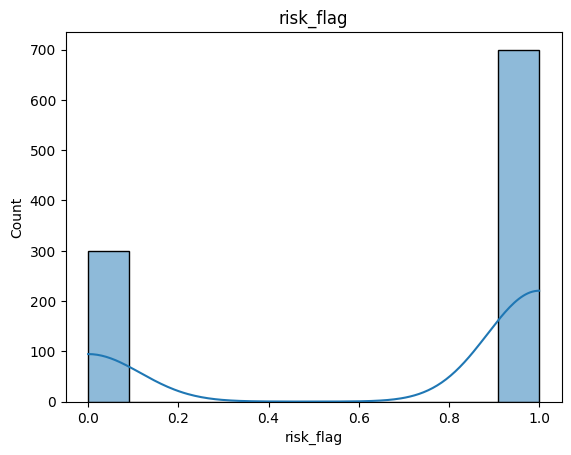

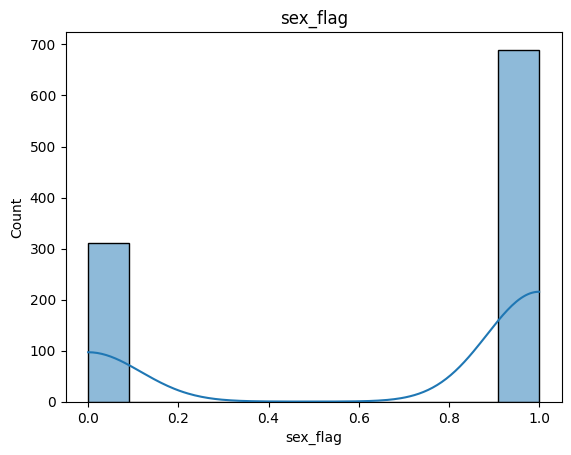

In [134]:
# Overview data in graph
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

3. Validation: Train/Validation/Test split with Regression

In [135]:
# Import necessary libraries for model training and evaluation
from sklearn.model_selection import train_test_split


In [136]:
df_final = df[['age','job','credit_amount','duration', 'sex_flag','risk_flag']].copy()
X = df_final.drop(columns=['risk_flag'])
y = df_final['risk_flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [137]:
print ("Intercept: ", model.intercept_)
print ("Coefficients", model.coef_)
y_pred = model.predict(X_test)
print("MSE: ", mean_squared_error(y_test,y_pred))
print("r2_score: ", r2_score(y_test,y_pred))

Intercept:  0.6493598608463667
Coefficients [ 4.80923200e-03 -8.14599996e-03 -1.21303497e-05 -5.90258999e-03
  8.70069701e-02]
MSE:  0.2051623967874693
r2_score:  0.013523756280950483


In [138]:
result_df_y_pred = round(pd.DataFrame(np.expm1(y_pred), columns = ['risk_flag']), 0)
result_df_y_pred

,risk_flag
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
195,1.0
196,0.0
197,1.0
198,1.0


4. Save Model

In [151]:
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
 
# Setting model parameters
C = 1.0
n_splits = 5
 
output_file = f'KM_model_CreditRisk={C}.bin'
 
# Data preparation
df = pd.read_csv(r'D:\Khosara\Training - Data Science\ML VS Code\Final Project\credit_data.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')

df['saving_accounts'] = df['saving_accounts'].fillna(df['saving_accounts'].mode()[0])
df['checking_account'] = df['checking_account'].fillna(df['checking_account'].mode()[0])

df['sex_flag'] = (df['sex'] == 'male').astype(int)
df['risk_flag'] = (df['risk'] == 'good').astype(int)

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')
 
# Data splitting
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

numerical = ['sex_flag', 'age', 'job', 'credit_amount', 'duration', 'sex_flag', 'risk_flag']
categorical = ['sex', 'housing', 'saving_accounts', 'checking_account', 'purpose', 'risk']
 
# Training
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
 
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
 
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)
 
    return dv, model
 
def predict(df, dv, model):
     dicts = df[categorical + numerical].to_dict(orient='records')
 
     X = dv.transform(dicts)
     y_pred = model.predict_proba(X)[:,1]
 
     return y_pred
 
# Validation
print(f'doing validation with C={C}')
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)  
     
scores = []
 
fold = 0
 
for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
 
    y_train = df_train.risk_flag.values
    y_val = df_val.risk_flag.values
 
    dv, model = train(df_train, y_train, C=C)
    y_pred = predict(df_val, dv, model)
 
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
 
    print(f'auc on fold {fold} is {auc}')
    fold += 1
 
print('validation result:')
print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))
 
# Train the final model
print('train the final model')
dv, model = train(df_full_train, df_full_train.risk_flag.values, C=1.0)
y_pred = predict(df_test, dv, model)
y_test = df_test.risk_flag.values
 
auc = roc_auc_score(y_test, y_pred)

print(f'auc={auc}')

 
# Saving the model with Pickle
with open(output_file, 'wb') as f_out:
    pickle.dump((dv, model), f_out)
 
print(f'the model is saved to {output_file}')

doing validation with C=1.0


C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:38: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df_train[categorical + numerical].to_dict(orient='records')
d:\Khosara\Training - Data Science\ML VS Code\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:49: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df[categorical + 

auc on fold 0 is 1.0


d:\Khosara\Training - Data Science\ML VS Code\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:49: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df[categorical + numerical].to_dict(orient='records')
C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:38: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df_train[categorical + 

auc on fold 1 is 1.0


...

d:\Khosara\Training - Data Science\ML VS Code\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:49: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df[categorical + numerical].to_dict(orient='records')
C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:38: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df_train[categorical + 

auc on fold 3 is 1.0


C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:49: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df[categorical + numerical].to_dict(orient='records')
C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:38: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df_train[categorical + numerical].to_dict(orient='records')


auc on fold 4 is 1.0
validation result:
C=1.0 1.000 +- 0.000
train the final model
auc=1.0
the model is saved to KM_model_CreditRisk=1.0.bin


C:\Users\USer\AppData\Local\Temp\ipykernel_1272\4045039301.py:49: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dicts = df[categorical + numerical].to_dict(orient='records')
